In [1]:
import numpy as np
from torchvision import datasets
import matplotlib.pyplot as plt

import models
import utils
import inference

In [2]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True)

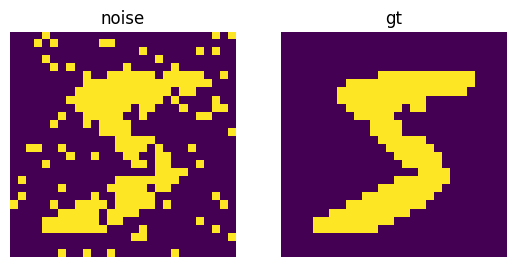

In [6]:
idx = 0

image, _ = train_dataset[idx]
image = (np.array(image) > 0.5).astype(int)

eps = 0.1
mask = np.random.random(image.shape) > 1 - eps
noise_image = image.copy()
noise_image[mask] = 1-noise_image[mask]

plt.subplot(1, 2, 1)
plt.title('noise')
plt.imshow(noise_image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('gt')
plt.imshow(image)
plt.axis('off')
plt.show()

In [4]:
alpha = 1
beta = 1
max_iter = 100

graph = utils.noise_graph_from_image(noise_image, alpha, beta)
marginals = inference.loopy_bp(graph, max_iter)

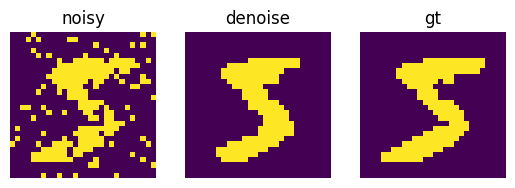

In [ ]:
im = utils.image_from_marginals(image, marginals)

plt.subplot(1, 3, 1)
plt.title('noisy')
plt.imshow(noise_image)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('denoise')
plt.imshow(im)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('gt')
plt.imshow(image)
plt.axis('off')

plt.show()